In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [3]:
house=pd.read_csv("train.csv")

In [4]:
house.shape

(1460, 81)

In [5]:
house.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [8]:
house.drop("Id", axis=1, inplace=True)

## Separate Features and Target

In [10]:
X = house.drop("SalePrice", axis=1)
y = house["SalePrice"]

In [11]:
X.isnull().sum().sort_values(ascending=False).head(10)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
dtype: int64

In [12]:
X = X.fillna(X.median(numeric_only=True))

In [13]:
X = X.fillna("None")

In [14]:
X = pd.get_dummies(X, drop_first=True)

In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Feature Scaling

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Train Ridge Regression

In [17]:
from sklearn.linear_model import RidgeCV

ridge = RidgeCV(alphas=[0.01,0.1,1,10,100],cv=5)
ridge.fit(X_train,y_train)

ridge_pred = ridge.predict(X_test)

## Train Lasso Regression

In [19]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5,max_iter=100000)
lasso.fit(X_train,y_train)

lasso_pred = lasso.predict(X_test)

## Train ElasticNet

In [20]:
from sklearn.linear_model import ElasticNetCV

elastic = ElasticNetCV(l1_ratio=[.1,.3,.5,.7,.9,1],cv=5,max_iter=100000)
elastic.fit(X_train,y_train)

elastic_pred = elastic.predict(X_test)

In [22]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

def evaluate(name, y_test, pred):
    print(name)
    print("R2:", r2_score(y_test, pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
    print()

In [23]:
evaluate("Ridge", y_test, ridge_pred)
evaluate("Lasso", y_test, lasso_pred)
evaluate("ElasticNet", y_test, elastic_pred)

Ridge
R2: 0.8612074418741139
RMSE: 32627.966469817373

Lasso
R2: 0.824541547533321
RMSE: 36685.46805245457

ElasticNet
R2: 0.824541547533321
RMSE: 36685.46805245457



In [24]:
import numpy as np
print("Total features:", X.shape[1])
print("Ridge non-zero:", np.sum(ridge.coef_!=0))
print("Lasso non-zero:", np.sum(lasso.coef_!=0))

Total features: 260
Ridge non-zero: 258
Lasso non-zero: 31


## Plot 1 — Compare Coefficients

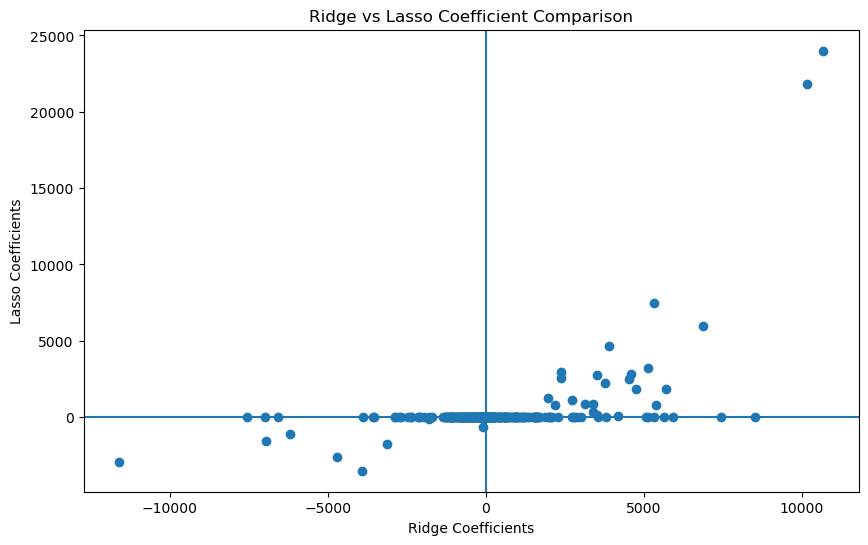

In [25]:
import numpy as np
import matplotlib.pyplot as plt

ridge_coef = ridge.coef_
lasso_coef = lasso.coef_

plt.figure(figsize=(10,6))

plt.scatter(ridge_coef, lasso_coef)
plt.axhline(0)
plt.axvline(0)

plt.xlabel("Ridge Coefficients")
plt.ylabel("Lasso Coefficients")
plt.title("Ridge vs Lasso Coefficient Comparison")

plt.show()

How to read this graph

Each dot = one feature

What you will see

Many dots on y = 0 line → Lasso removed those features

But x ≠ 0 → Ridge kept them

Meaning:

Those features still contained useful signal → Ridge used them → better R²

## Plot 2 — Number of Features Used

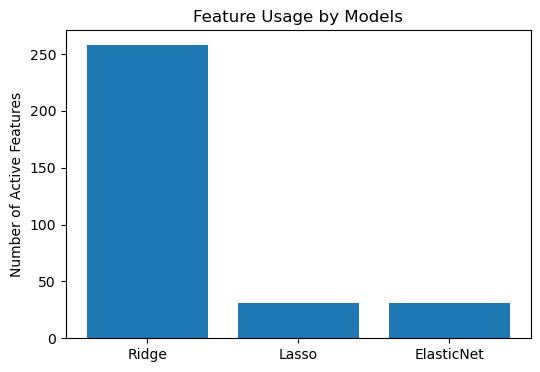

In [26]:
ridge_nonzero = np.sum(ridge.coef_ != 0)
lasso_nonzero = np.sum(lasso.coef_ != 0)
elastic_nonzero = np.sum(elastic.coef_ != 0)

models = ["Ridge","Lasso","ElasticNet"]
values = [ridge_nonzero,lasso_nonzero,elastic_nonzero]

plt.figure(figsize=(6,4))
plt.bar(models,values)

plt.ylabel("Number of Active Features")
plt.title("Feature Usage by Models")
plt.show()

Ridge performed better because the dataset contained many correlated predictors contributing small information, and removing them using Lasso caused loss of predictive power.